In [2]:
!pip install python-rake
!pip install nltk
!pip install rake-nltk

In [3]:
!pip install scikit-plot
!pip install wordcloud


In [4]:
import pandas as pd
from rake_nltk import Rake
import operator
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt')
import wordcloud as w
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,make_scorer,classification_report,accuracy_score
import scikitplot as skplt
from sklearn import svm
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\91913\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


## Import the CSV File

In [5]:
### FLOW GENERATORS ###
# loading the directories

# job_postings = 'D:\CAPSTONE\DATASETdice_com-job_us_sample.csv'
df_job = pd.read_csv('D:\CAPSTONE\DATASET\dice_com-job_us_sample.csv')


# Preview the first 5 lines of the loaded data
df_job.head()

,advertiserurl,company,employmenttype_jobstatus,jobdescription,jobid,joblocation_address,jobtitle,postdate,shift,site_name,skills,uniq_id
0,https://www.dice.com/jobs/detail/AUTOMATION-TE...,"Digital Intelligence Systems, LLC","C2H Corp-To-Corp, C2H Independent, C2H W2, 3 M...",Looking for Selenium engineers...must have sol...,Dice Id : 10110693,"Atlanta, GA",AUTOMATION TEST ENGINEER,1 hour ago,Telecommuting not available|Travel not required,NaN,SEE BELOW,418ff92580b270ef4e7c14f0ddfc36b4
1,https://www.dice.com/jobs/detail/Information-S...,University of Chicago/IT Services,Full Time,The University of Chicago has a rapidly growin...,Dice Id : 10114469,"Chicago, IL",Information Security Engineer,1 week ago,Telecommuting not available|Travel not required,NaN,"linux/unix, network monitoring, incident respo...",8aec88cba08d53da65ab99cf20f6f9d9
2,https://www.dice.com/jobs/detail/Business-Solu...,"Galaxy Systems, Inc.",Full Time,"GalaxE.SolutionsEvery day, our solutions affec...",Dice Id : CXGALXYS,"Schaumburg, IL",Business Solutions Architect,2 weeks ago,Telecommuting not available|Travel not required,NaN,"Enterprise Solutions Architecture, business in...",46baa1f69ac07779274bcd90b85d9a72
3,https://www.dice.com/jobs/detail/Java-Develope...,TransTech LLC,Full Time,Java DeveloperFull-time/direct-hireBolingbrook...,Dice Id : 10113627,"Bolingbrook, IL","Java Developer (mid level)- FT- GREAT culture,...",2 weeks ago,Telecommuting not available|Travel not required,NaN,Please see job description,3941b2f206ae0f900c4fba4ac0b18719
4,https://www.dice.com/jobs/detail/DevOps-Engine...,Matrix Resources,Full Time,Midtown based high tech firm has an immediate ...,Dice Id : matrixga,"Atlanta, GA",DevOps Engineer,48 minutes ago,Telecommuting not available|Travel not required,NaN,"Configuration Management, Developer, Linux, Ma...",45efa1f6bc65acc32bbbb953a1ed13b7


# 2. Cleaning of Data

**2.1 Remove unnecesary columns**

In [6]:
print(df_job.columns)

Index(['advertiserurl', 'company', 'employmenttype_jobstatus',
       'jobdescription', 'jobid', 'joblocation_address', 'jobtitle',
       'postdate', 'shift', 'site_name', 'skills', 'uniq_id'],
      dtype='object')


In [7]:
# Remove postdate, shift, sitename
df_job.drop('postdate', inplace=True, axis=1)
df_job.drop('shift',inplace=True, axis=1)
df_job.drop('site_name', inplace=True, axis =1)
df_job.drop('uniq_id', inplace=True, axis =1)
df_job.drop('jobid', inplace=True, axis =1)

# Preview the first 5 Lines of the loaded data
df_job.head()

,advertiserurl,company,employmenttype_jobstatus,jobdescription,joblocation_address,jobtitle,skills
0,https://www.dice.com/jobs/detail/AUTOMATION-TE...,"Digital Intelligence Systems, LLC","C2H Corp-To-Corp, C2H Independent, C2H W2, 3 M...",Looking for Selenium engineers...must have sol...,"Atlanta, GA",AUTOMATION TEST ENGINEER,SEE BELOW
1,https://www.dice.com/jobs/detail/Information-S...,University of Chicago/IT Services,Full Time,The University of Chicago has a rapidly growin...,"Chicago, IL",Information Security Engineer,"linux/unix, network monitoring, incident respo..."
2,https://www.dice.com/jobs/detail/Business-Solu...,"Galaxy Systems, Inc.",Full Time,"GalaxE.SolutionsEvery day, our solutions affec...","Schaumburg, IL",Business Solutions Architect,"Enterprise Solutions Architecture, business in..."
3,https://www.dice.com/jobs/detail/Java-Develope...,TransTech LLC,Full Time,Java DeveloperFull-time/direct-hireBolingbrook...,"Bolingbrook, IL","Java Developer (mid level)- FT- GREAT culture,...",Please see job description
4,https://www.dice.com/jobs/detail/DevOps-Engine...,Matrix Resources,Full Time,Midtown based high tech firm has an immediate ...,"Atlanta, GA",DevOps Engineer,"Configuration Management, Developer, Linux, Ma..."


**2.2 Remove Duplicates**

In [8]:
df_job.drop_duplicates()
df_job.head(5)

,advertiserurl,company,employmenttype_jobstatus,jobdescription,joblocation_address,jobtitle,skills
0,https://www.dice.com/jobs/detail/AUTOMATION-TE...,"Digital Intelligence Systems, LLC","C2H Corp-To-Corp, C2H Independent, C2H W2, 3 M...",Looking for Selenium engineers...must have sol...,"Atlanta, GA",AUTOMATION TEST ENGINEER,SEE BELOW
1,https://www.dice.com/jobs/detail/Information-S...,University of Chicago/IT Services,Full Time,The University of Chicago has a rapidly growin...,"Chicago, IL",Information Security Engineer,"linux/unix, network monitoring, incident respo..."
2,https://www.dice.com/jobs/detail/Business-Solu...,"Galaxy Systems, Inc.",Full Time,"GalaxE.SolutionsEvery day, our solutions affec...","Schaumburg, IL",Business Solutions Architect,"Enterprise Solutions Architecture, business in..."
3,https://www.dice.com/jobs/detail/Java-Develope...,TransTech LLC,Full Time,Java DeveloperFull-time/direct-hireBolingbrook...,"Bolingbrook, IL","Java Developer (mid level)- FT- GREAT culture,...",Please see job description
4,https://www.dice.com/jobs/detail/DevOps-Engine...,Matrix Resources,Full Time,Midtown based high tech firm has an immediate ...,"Atlanta, GA",DevOps Engineer,"Configuration Management, Developer, Linux, Ma..."


**2.3 Drop Empty and rubbish words**

In [9]:
#check to see if we have any missing values at all.
print(df_job.isnull ().values.any ())
# since the above results is true, check number of missing values in each row
df_job.isna().sum()

True


advertiserurl                 0
company                      50
employmenttype_jobstatus    230
jobdescription                0
joblocation_address           3
jobtitle                      0
skills                       43
dtype: int64

In [10]:
# Total number of missing values
df_job.isnull().sum().sum()

326

In [11]:
#drop all rows that have any NaN values
df_job.dropna(inplace=True)

##check that there is no more na
df_job.isna().sum()

advertiserurl               0
company                     0
employmenttype_jobstatus    0
jobdescription              0
joblocation_address         0
jobtitle                    0
skills                      0
dtype: int64

In [12]:
# Get index of all rows in skills that contains the value "Null"
jobsNull = df_job[df_job["skills"]=="Null"]. index
# Get index of all rows in skills that contains the value "Please see job description"
jobsDesc1 = df_job[df_job["skills"]=="Please see job description"].index
# Get index of all rows in skills that contains the value (See Job Description)
jobsDesc2 = df_job[df_job["skills"]==" (See Job Description)"]. index
# Get index of all rows in skills that contains the value "SEE BELOW*
jobsDesc3 = df_job[df_job["skills"]=="SEE BELOW"]. index
# Get index of all rows in skills that contains the value "Telecommuting not available Travel not required"
jobsDesc4 = df_job[df_job["skills"]=="Telecommuting not available Travel not required"]. index
# Get index of all rows in skills that contains the value "Refer to Job Description"
jobsDesc5 = df_job[df_job["skills"]=="Refer to Job Description"].index
# Get index of all rows in skills that contains the value "Please see Required Skills"
jobsDesc6 = df_job[df_job["skills"]=="Please see Required Skills"].index
# drop rows of index
df_job.drop(jobsNull, inplace=True)
df_job.drop(jobsDesc1, inplace=True)
df_job.drop(jobsDesc2, inplace=True)
df_job.drop(jobsDesc3, inplace=True)
df_job.drop(jobsDesc4, inplace=True)
df_job.drop(jobsDesc5, inplace=True)
df_job.drop(jobsDesc6, inplace=True)

In [13]:
#Print info of Dataframe
df_job.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 21621 entries, 1 to 21998
Data columns (total 7 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   advertiserurl             21621 non-null  object
 1   company                   21621 non-null  object
 2   employmenttype_jobstatus  21621 non-null  object
 3   jobdescription            21621 non-null  object
 4   joblocation_address       21621 non-null  object
 5   jobtitle                  21621 non-null  object
 6   skills                    21621 non-null  object
dtypes: object(7)
memory usage: 1.3+ MB


# **Data Visualisation of the data**

**1. Top 5 most demanded jobs**

In [14]:
# See the top 5 highest frequency of job titles
df_job["jobtitle"].value_counts ()[:5]

Java Developer       174
Project Manager      144
Network Engineer     127
Software Engineer    118
Business Analyst     117
Name: jobtitle, dtype: int64

In [15]:
job = []
stopwordsList = []
cleanJobs = []
# Get the stopwords and store in list
with open("D:\CAPSTONE\DATASET\stopwords.txt", 'r', encoding="utf-8") as f:
    for word in f:
        word = word.split('\n')
        stopwordsList.append(word[0])

# Tokenizing and Removing stop words from jobtitle

from nltk.tokenize import word_tokenize
import nltk

# Convert all words to lower case and change the shortform
for i in df_job['jobtitle'].values:
  jobs = i. lower ()
  jobs = jobs.replace("QA", "Quality Assurance")
  jobs = jobs.replace("sr", "Senior")
  jobs = jobs.replace("jr", "Junior")
  jobs = jobs.replace("qm", "Quality Manager")
  job.append (jobs)

# tokenize and remove the words from stop words
for j in job:
    text_tokens = word_tokenize(j)
    tokens_without_sw = [f for f in text_tokens if not f in stopwordsList]
    cleanJobs .append(' '.join(tokens_without_sw))

In [16]:
# Add the newly cleaned job title into the dataframe
df_job['clean_jobtitle'] = cleanJobs
df_job.head(5)

,advertiserurl,company,employmenttype_jobstatus,jobdescription,joblocation_address,jobtitle,skills,clean_jobtitle
1,https://www.dice.com/jobs/detail/Information-S...,University of Chicago/IT Services,Full Time,The University of Chicago has a rapidly growin...,"Chicago, IL",Information Security Engineer,"linux/unix, network monitoring, incident respo...",information security engineer
2,https://www.dice.com/jobs/detail/Business-Solu...,"Galaxy Systems, Inc.",Full Time,"GalaxE.SolutionsEvery day, our solutions affec...","Schaumburg, IL",Business Solutions Architect,"Enterprise Solutions Architecture, business in...",business solutions architect
4,https://www.dice.com/jobs/detail/DevOps-Engine...,Matrix Resources,Full Time,Midtown based high tech firm has an immediate ...,"Atlanta, GA",DevOps Engineer,"Configuration Management, Developer, Linux, Ma...",devops engineer
5,https://www.dice.com/jobs/detail/SAP-FICO-Arch...,Yash Technologies,"Full Time, Permanant",We are looking for a Senior SAP FICO Architect...,"Chicago, IL",SAP FICO Architect,"FICO, AR, AP, Asset Management, HAHA",sap fico architect
6,https://www.dice.com/jobs/detail/Network-Engin...,Noble1,"Full Time, Direct Hire",Network Engineer Job Description A Network Eng...,"Atlanta, GA",Network Engineer,"Cisco, DNS, HTTP, Networking, Network Engineer...",network engineer


In [17]:
# Get the Top 5 Jobs
qty = df_job["clean_jobtitle"].value_counts()[:5].tolist ()
label = df_job["clean_jobtitle"].value_counts () [:5]. index. tolist ()
print(qty)
print("Top 5 Popular Jobs :" + str(label))

[194, 175, 132, 130, 129]
Top 5 Popular Jobs :['java developer', 'project manager', 'business analyst', 'network engineer', '.net developer']


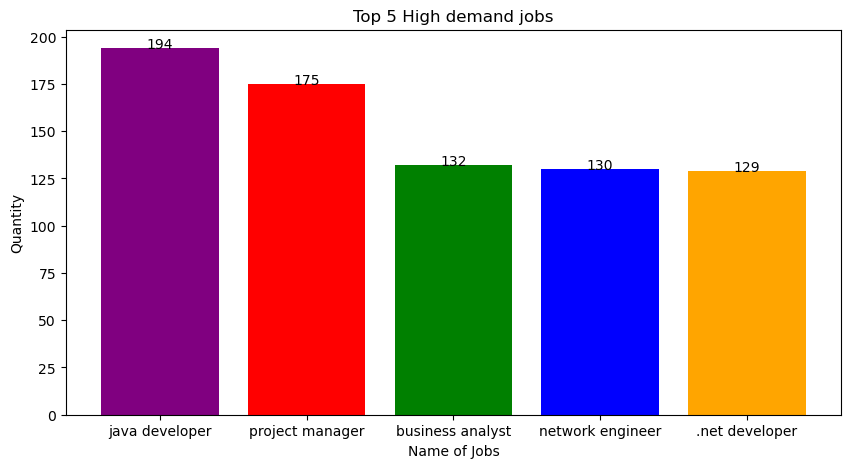

In [18]:
def addlabels(x,y):
  for i in range(len(x)):
    plt.text(i, y[i], y[i], ha = 'center')

## initializing the labels
skillslabel = label
jobQty = qty

# setting figure size by using figure() function
plt.figure(figsize = (10, 5))

# making the bar chart on the data
plt.bar(skillslabel, jobQty,color=[ 'purple', 'red', 'green', 'blue', 'orange'])

# calling the function to add value Labels
addlabels(skillslabel, jobQty)

# giving title to the plot
plt.title("Top 5 High demand jobs")

# giving X and Y Labels
plt.xlabel("Name of Jobs")
plt.ylabel("Quantity")

#visualizing the plot
plt.show()

**2. Most Used Skills**

In [19]:
skillsTokenized = []
stopwordsskills = []

# Get the stopwords and store in list
with open("D:\CAPSTONE\DATASET\stopwords.txt", 'r', encoding="utf-8") as f:
    for word in f:
      word.lower()
      word = word.split('\n')

      stopwordsskills.append(word[0])

for k in df_job['skills'].values:
  k = str(k).split(', ')
  #remove stopwords from skills
  skillstokens_without_sw = [f for f in k if not f.lower() in stopwordsskills]
  for j in skillstokens_without_sw:
    skillsTokenized.append(j)

#put the cleaned skills into a new dataframe
df = pd.DataFrame({'skills':skillsTokenized})

In [20]:
#Get the top 5 skills
qtySkills = df["skills"].value_counts().tolist()
labelSkills = df["skills"].value_counts().index.tolist()
print("Top 5 skills mostly needed \n" + str(df["skills"].value_counts()[:5]))

Top 5 skills mostly needed 
Development    1680
Java           1668
SQL            1559
Management     1509
JavaScript     1012
Name: skills, dtype: int64


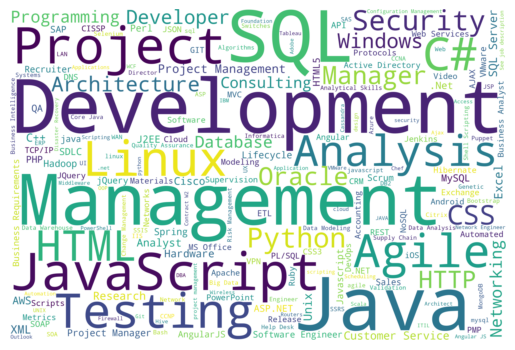

<Figure size 300000x300000 with 0 Axes>

In [21]:
import wordcloud as w
import numpy as np
import matplotlib.pyplot as plt

lskills = labelSkills
frequencies = qtySkills

#Wordcloud asks for a string, and we have tried seperating the terms with ',' and '-'

d = dict(zip(lskills,frequencies))
wordcloud = w.WordCloud(collocations = False, random_state=1,background_color='White', width=3000,height = 2000).generate_from_frequencies(d)

plt.imshow(wordcloud,interpolation = 'bilinear')
plt.axis("off")
plt.figure(figsize = (3000,3000))
plt.show()

# **3. Data Mining**

**3.1 TF-IDF**

In [22]:
vectorizer = TfidfVectorizer ()
X = vectorizer.fit_transform(df_job['clean_jobtitle'].values)
print(X.shape)
analyze = vectorizer.build_analyzer()
# print( 'Job titles', analyze(str(jobtitle)))
# print ('Document transform', X. toarray ())
# print(vectorizer.get_feature_names())
features = vectorizer.get_feature_names_out()
# indices = zip(*X.nonzero)
# for row, column in indices:
#   print(' (%d, %s) %f' %(row, features [column], X[row, column]))

(21621, 4829)


# **4. Clustering using K - Means**

4.1 getting Optimize cluster using elbow method

In [23]:
from sklearn.cluster import KMeans
# Using the elbow method to find the optimal number of clusters
# Within Cluster Sum of Squares(WCSS)
wcss =[]
for i in range (1,15):
    kmeans = KMeans(n_clusters = i,init='k-means++',random_state = 42,max_iter = 600,n_init = 1)
    kmeans.fit(X)
    #inertia method returns wcss for the model
    wcss.append(kmeans.inertia_)

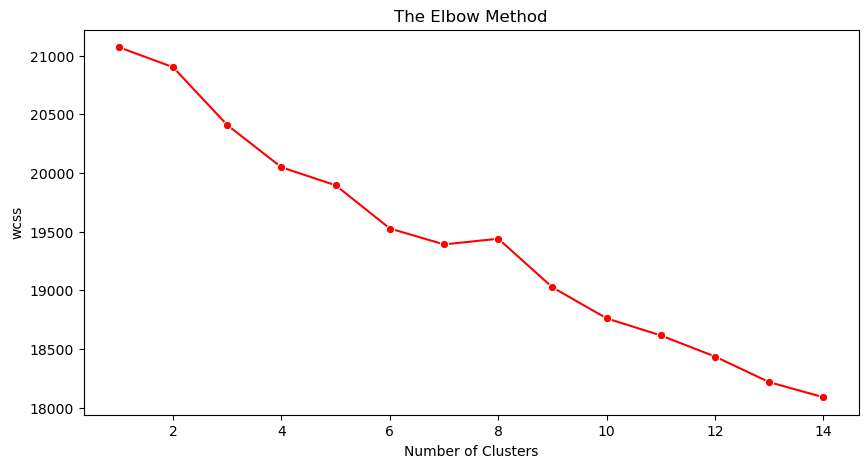

In [24]:
import seaborn as sns
#plotting the graph
plt.figure(figsize=(10,5))
sns.lineplot(x=range(1, 15), y=wcss, marker='o', color='red')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('wcss')
plt.show()

In [25]:
true_k = 7  # Set the desired number of clusters
model = KMeans(n_clusters=true_k, init='k-means++', max_iter=600, n_init=1, random_state=42)
pred = model.fit_predict(X)
order_centeroids = model.cluster_centers_.argsort()[:,::-1]
terms = vectorizer.get_feature_names_out()

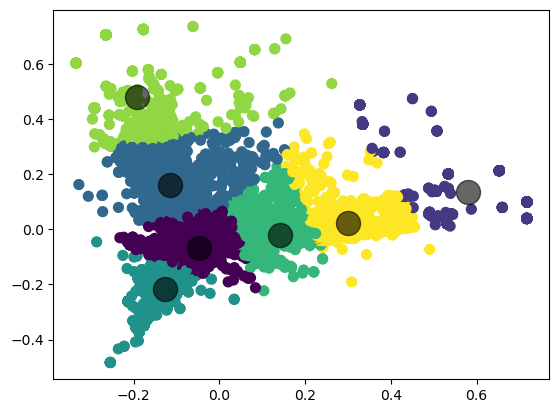

In [26]:
from sklearn.cluster import KMeans
from sklearn. decomposition import PCA

sklearn_pca = PCA(n_components = 2)

Y_sklearn = sklearn_pca.fit_transform(X. toarray())
kmeans = KMeans(n_clusters=7, init='k-means++', max_iter=600, n_init=1, random_state=42)
fitted = kmeans.fit (Y_sklearn)
prediction = kmeans.predict (Y_sklearn)

plt.scatter(Y_sklearn[:, 0], Y_sklearn[:, 1], c=prediction, s=50, cmap='viridis')

ceriters = kmeans.cluster_centers_
plt.scatter(ceriters[:, 0], ceriters[:, 1], c='black', s=300, alpha=0.6);

In [27]:
# Silhouette score value ranges from -1 to 1.
# metric used to calculate the goodness of a clustering technique
# 1: Means clusters are well apart from each other and clearly distinguished
from sklearn.metrics import silhouette_score
print ('KMeans Scaled Silhouette Score: {}'.format(silhouette_score(X, model.labels_, metric = 'euclidean' )))

KMeans Scaled Silhouette Score: 0.04052548587593584


In [28]:
def get_top_keywords (data, clusters, labels, n_terms):
  df = pd.DataFrame(data.todense()).groupby(clusters).mean()
  for i,r in df.iterrows():
    print('\ncluster {}'.format(i))
    print(','.join([labels[t] for t in np.argsort(r)[-n_terms: ]]))

get_top_keywords(X, pred, features, 10)


cluster 0
cyber,architect,network,sap,analyst,senior,information,engineer,consultant,security

cluster 1
application,ui,stack,software,front,web,senior,net,java,developer

cluster 2
technical,specialist,systems,support,senior,data,administrator,business,architect,analyst

cluster 3
infrastructure,coordinator,business,development,program,technical,product,senior,project,manager

cluster 4
net,software,team,architect,tech,engineer,java,developer,technical,lead

cluster 5
java,data,development,test,devops,systems,network,senior,software,engineer

cluster 6
senior,technical,ts,account,executive,cs,recruiter,robert,half,technology


In [29]:
## Do further classification, Give the 0,1,2,3 a name to understand better
#Cluster 0 - Project Management, cluster 1- frontend , cluster 2 - Devops/Software Engineer,
#cluster 3 = Business Solution Consultant, cluster 4 • Cloud Architect/Network,
#cluster 5= Analyst, cluster 6 - IT Business Management
label = []
for i in df_job['clean_jobtitle'].values:
      vec = vectorizer.transform([i])
      pred = model.predict (vec)
      if pred == 0:
          label.append("Project Management")
      elif pred == 1:
          label.append("Frontend")
      elif pred == 2:
          label.append("Devops/Software Engineer")
      elif pred == 3:
          label.append("Business Solution Consultant")
      elif pred == 4:
          label.append("Cloud Architect/Network")
      elif pred == 5:
          label.append("Analyst")
      else:
          label.append("IT Business Management")

df_job['Label'] = label
df_job.head(5)

,advertiserurl,company,employmenttype_jobstatus,jobdescription,joblocation_address,jobtitle,skills,clean_jobtitle,Label
1,https://www.dice.com/jobs/detail/Information-S...,University of Chicago/IT Services,Full Time,The University of Chicago has a rapidly growin...,"Chicago, IL",Information Security Engineer,"linux/unix, network monitoring, incident respo...",information security engineer,Project Management
2,https://www.dice.com/jobs/detail/Business-Solu...,"Galaxy Systems, Inc.",Full Time,"GalaxE.SolutionsEvery day, our solutions affec...","Schaumburg, IL",Business Solutions Architect,"Enterprise Solutions Architecture, business in...",business solutions architect,Devops/Software Engineer
4,https://www.dice.com/jobs/detail/DevOps-Engine...,Matrix Resources,Full Time,Midtown based high tech firm has an immediate ...,"Atlanta, GA",DevOps Engineer,"Configuration Management, Developer, Linux, Ma...",devops engineer,Analyst
5,https://www.dice.com/jobs/detail/SAP-FICO-Arch...,Yash Technologies,"Full Time, Permanant",We are looking for a Senior SAP FICO Architect...,"Chicago, IL",SAP FICO Architect,"FICO, AR, AP, Asset Management, HAHA",sap fico architect,Devops/Software Engineer
6,https://www.dice.com/jobs/detail/Network-Engin...,Noble1,"Full Time, Direct Hire",Network Engineer Job Description A Network Eng...,"Atlanta, GA",Network Engineer,"Cisco, DNS, HTTP, Networking, Network Engineer...",network engineer,Analyst


In [30]:
jobSkills = []
for i in df_job['skills']:
    jobSkills.append(i.lower ())

Xclass = vectorizer.fit_transform(jobSkills)
#Split data into test and train. Test size 20% Train Size 80%
X_train,X_test,y_train,y_test = train_test_split(Xclass, label, test_size=0.2, random_state=42)

Text(0, 0.5, 'Accuracy')

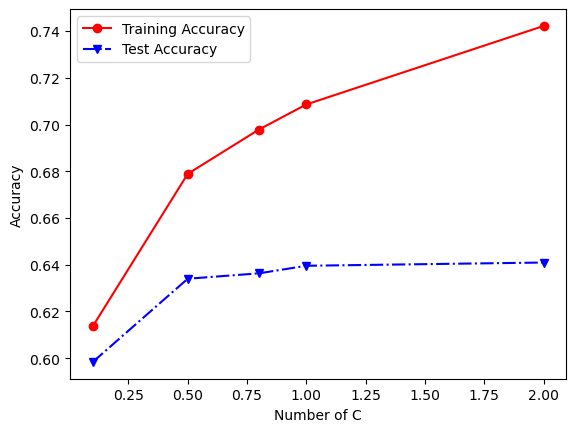

In [31]:
# Obtain the best C range
Cparamrange = [0.1,0.5,0.8,1,2]
trainAcc = []
testAcc = []
for i in Cparamrange:
    lrg = LogisticRegression(penalty = 'l2', C = i,random_state = 42)
    lrg.fit(X_train,y_train)
    lrg_predtrain=lrg.predict(X_train)
    lrg_predtest=lrg.predict(X_test)
    trainacc = accuracy_score (y_train, lrg_predtrain)
    testacc = accuracy_score(y_test,lrg_predtest)
    trainAcc.append(trainacc)
    testAcc. append(testacc)

plt.plot(Cparamrange, trainAcc,'ro-', Cparamrange, testAcc, 'bv-.')
plt. legend(['Training Accuracy', 'Test Accuracy ' ])
plt.xlabel('Number of C')
plt.ylabel('Accuracy')

**C=1 is able to get the optimal accuracy**

In [32]:
# using the best c param range
lrg = LogisticRegression(penalty = 'l2', C = 1, random_state = 42)
lrg.fit(X_train,y_train)
lrg_pred=lrg.predict(X_test)
lrg_acc = accuracy_score(y_test,lrg_pred)
print ("Accuracy of Logistic Regression: " + str(lrg_acc))
print(classification_report (y_test, lrg_pred))

Accuracy of Logistic Regression: 0.6395375722543353
                              precision    recall  f1-score   support

                     Analyst       0.64      0.46      0.53       721
Business Solution Consultant       0.75      0.50      0.60       309
     Cloud Architect/Network       0.70      0.13      0.21       206
    Devops/Software Engineer       0.62      0.83      0.71      1908
                    Frontend       0.64      0.61      0.63       842
      IT Business Management       0.95      0.79      0.86        47
          Project Management       0.70      0.39      0.50       292

                    accuracy                           0.64      4325
                   macro avg       0.71      0.53      0.58      4325
                weighted avg       0.65      0.64      0.62      4325



<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

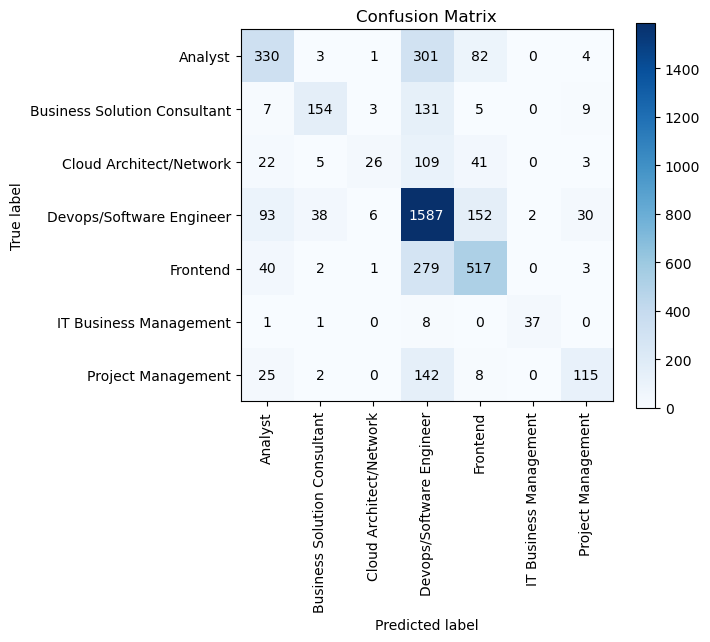

In [33]:
#plot confusion matrix
skplt.metrics.plot_confusion_matrix(
      y_test,
      lrg_pred,
      x_tick_rotation=90,
      figsize=(6,5))

**5.2 KNeighbors classifier**

Text(0, 0.5, 'Accuracy')

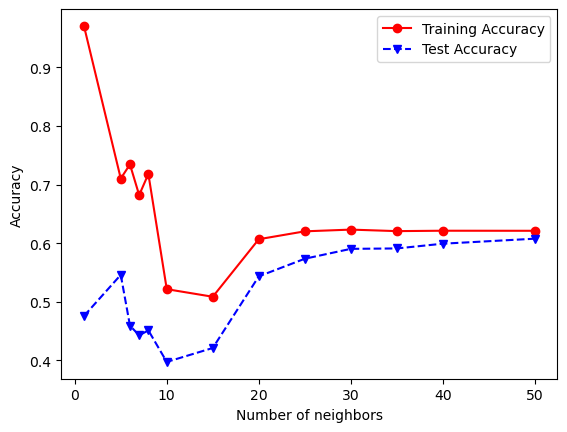

In [34]:
from sklearn.neighbors import KNeighborsClassifier
%matplotlib inline

numNeighbors = [1, 5, 6, 7, 8, 10, 15, 20, 25, 30, 35, 40, 50]
trainAcc = []
testAcc = []

for k in numNeighbors:
    clf1 = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=2)
    clf1.fit(X_train, y_train)
    Y_predTrain = clf1.predict(X_train)
    Y_predTest = clf1.predict(X_test)
    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))

plt.plot(numNeighbors, trainAcc, 'ro-', numNeighbors, testAcc,'bv--')
plt.legend([ 'Training Accuracy', 'Test Accuracy'])
plt.xlabel('Number of neighbors')
plt.ylabel( 'Accuracy')

In [35]:
knn = KNeighborsClassifier(n_neighbors=50, metric='minkowski', p=2)
knn. fit (X_train, y_train)
knn_pred = clf1.predict(X_test)
knn_acc = accuracy_score (y_test, knn_pred)
print("Accuracy of KNN: " + str (knn_acc))
print(classification_report(y_test, knn_pred))

Accuracy of KNN: 0.6076300578034682
                              precision    recall  f1-score   support

                     Analyst       0.61      0.41      0.49       721
Business Solution Consultant       0.65      0.45      0.53       309
     Cloud Architect/Network       1.00      0.04      0.07       206
    Devops/Software Engineer       0.63      0.75      0.68      1908
                    Frontend       0.54      0.76      0.63       842
      IT Business Management       0.62      0.79      0.69        47
          Project Management       0.73      0.29      0.42       292

                    accuracy                           0.61      4325
                   macro avg       0.68      0.50      0.50      4325
                weighted avg       0.63      0.61      0.58      4325



<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

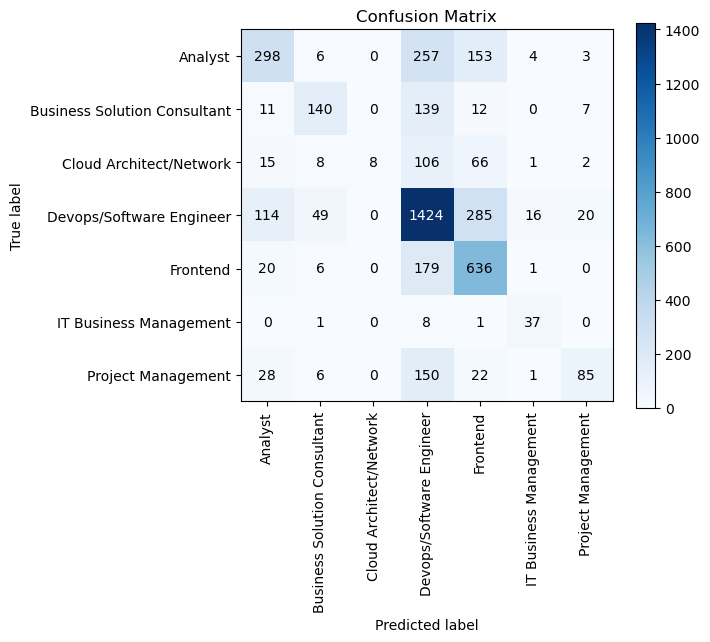

In [36]:
skplt.metrics.plot_confusion_matrix(
y_test,
knn_pred,
x_tick_rotation=90,
figsize= (6,5))

# **5.3 Decision tree**

Text(0, 0.5, 'Accuracy')

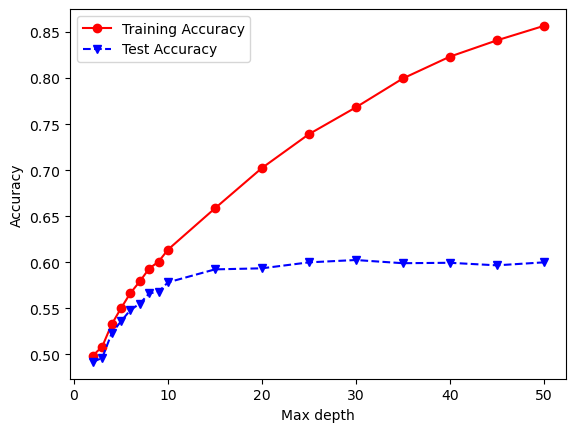

In [37]:
maxdepths = [2,3,4,5,6,7,8,9,10, 15, 20, 25,30,35,40,45,50] # 17 different depths
trainAccuracy = np.zeros(len(maxdepths))
testAccuracy = np.zeros(len(maxdepths))
index = 0
for depth in maxdepths:
    clf2 = DecisionTreeClassifier (max_depth=depth)
    clf2 = clf2.fit (X_train, y_train)
    Y_predTrain = clf2.predict (X_train)
    Y_predTest = clf2.predict(X_test)
    trainAccuracy[index] = accuracy_score(y_train, Y_predTrain)
    testAccuracy[index] = accuracy_score(y_test, Y_predTest)
    index += 1

# Plot training and test accuracies

plt.plot (maxdepths, trainAccuracy, 'ro-' , maxdepths, testAccuracy , 'bv--')
plt. legend(['Training Accuracy', 'Test Accuracy'])
plt.xlabel('Max depth')
plt.ylabel('Accuracy')

**let max_depth be 7**

In [38]:
dt = DecisionTreeClassifier(max_depth = 10)
dt2 = dt.fit(X_train, y_train)
dt_pred = dt2.predict(X_test)
dt_acc = accuracy_score(y_test,dt_pred)
print("Accuracy of Decision Trees: "+ str(dt_acc))
print(classification_report(y_test,dt_pred))


Accuracy of Decision Trees: 0.5771098265895954
                              precision    recall  f1-score   support

                     Analyst       0.63      0.24      0.35       721
Business Solution Consultant       0.71      0.38      0.49       309
     Cloud Architect/Network       0.62      0.19      0.29       206
    Devops/Software Engineer       0.57      0.81      0.67      1908
                    Frontend       0.55      0.61      0.58       842
      IT Business Management       0.97      0.62      0.75        47
          Project Management       0.58      0.28      0.38       292

                    accuracy                           0.58      4325
                   macro avg       0.66      0.45      0.50      4325
                weighted avg       0.59      0.58      0.55      4325



<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

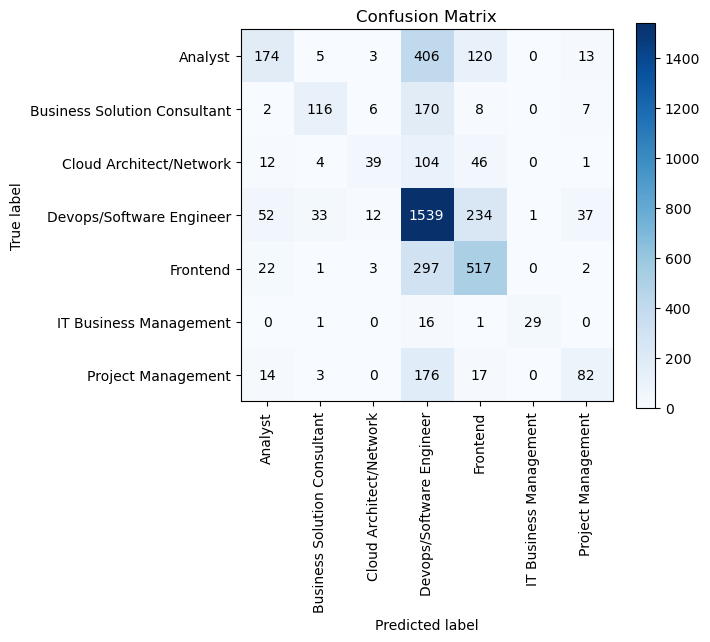

In [39]:
skplt.metrics.plot_confusion_matrix(
    y_test,
    dt_pred,
    x_tick_rotation = 90,
    figsize =(6,5)
)

# 5.4 SVM

In [40]:
from sklearn import svm

Text(0, 0.5, 'Accuracy')

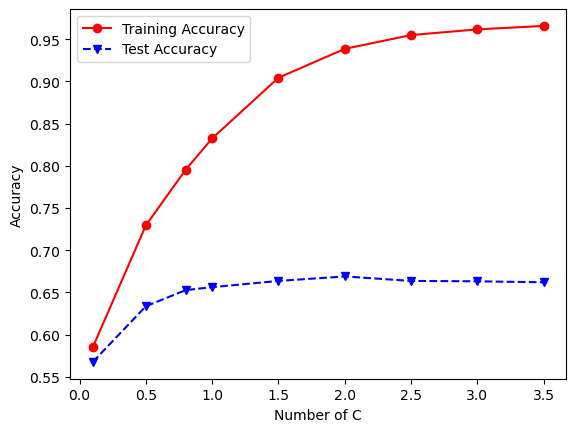

In [41]:
Csvm = [0.1,0.5,0.8,1,1.5, 2,2.5,3,3.5]
trainAcc = []
testAcc = []
for c in Csvm:
    modelsvm = svm.SVC(C= c, gamma= 1, kernel = 'rbf')
    svmfit = modelsvm.fit(X_train,y_train)
    Y_predTrain = modelsvm.predict(X_train)
    Y_predTest = modelsvm.predict (X_test)
    trainAcc.append(accuracy_score(y_train, Y_predTrain))
    testAcc.append(accuracy_score(y_test, Y_predTest))

plt.plot(Csvm, trainAcc,'ro-', Csvm, testAcc, 'bv--')
plt. legend(['Training Accuracy','Test Accuracy'])
plt.xlabel('Number of C')
plt.ylabel('Accuracy')

In [42]:
svm = svm.SVC(C= 5, gamma= 1, kernel= 'rbf' ,probability=True)
svmfit = svm.fit(X_train,y_train)
svm_predictions = svmfit.predict (X_test)
svm_acc = accuracy_score(y_test,svm_predictions)
print("Accuracy of SVM:" + str(svm_acc))
print(classification_report (y_test, svm_predictions))

Accuracy of SVM:0.6587283236994219
                              precision    recall  f1-score   support

                     Analyst       0.63      0.49      0.55       721
Business Solution Consultant       0.75      0.56      0.64       309
     Cloud Architect/Network       0.63      0.24      0.35       206
    Devops/Software Engineer       0.65      0.81      0.72      1908
                    Frontend       0.65      0.65      0.65       842
      IT Business Management       0.93      0.87      0.90        47
          Project Management       0.72      0.50      0.59       292

                    accuracy                           0.66      4325
                   macro avg       0.71      0.59      0.63      4325
                weighted avg       0.66      0.66      0.65      4325



<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

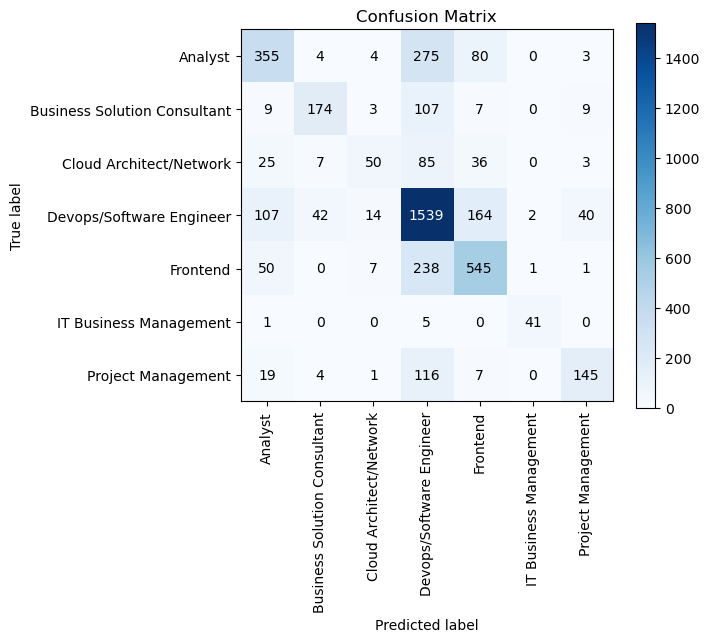

In [43]:
skplt.metrics.plot_confusion_matrix(
  y_test,
  svm_predictions,
  x_tick_rotation=90,
  figsize= (6,5))

# 5.4 Random Forest 

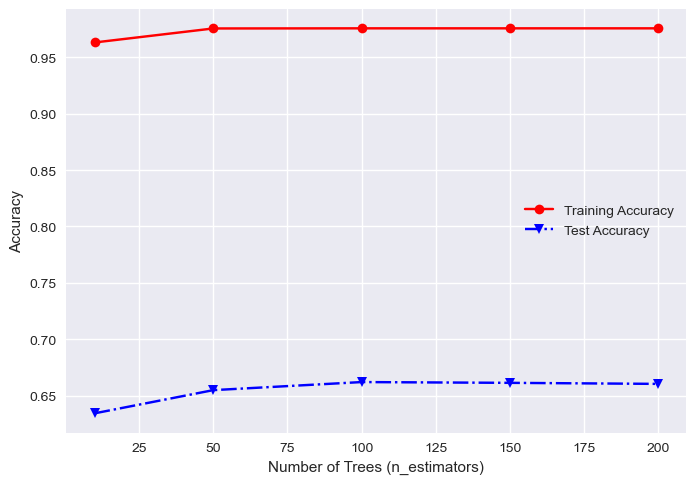

In [67]:
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

n_estimators_range = [10, 50, 100, 150, 200]  # Vary the number of trees
trainAcc = []
testAcc = []

for n_estimators in n_estimators_range:
    random_forest = RandomForestClassifier(n_estimators=n_estimators, random_state=42)
    random_forest.fit(X_train, y_train)
    random_forest_pred_train = random_forest.predict(X_train)
    random_forest_pred_test = random_forest.predict(X_test)
    train_acc = accuracy_score(y_train, random_forest_pred_train)
    test_acc = accuracy_score(y_test, random_forest_pred_test)
    trainAcc.append(train_acc)
    testAcc.append(test_acc)

plt.plot(n_estimators_range, trainAcc, 'ro-', n_estimators_range, testAcc, 'bv-.')
plt.legend(['Training Accuracy', 'Test Accuracy'])
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.show()

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

best_n_estimators = 100  # Replace with the best value you found
random_forest = RandomForestClassifier(n_estimators=best_n_estimators, random_state=42)
random_forest.fit(X_train, y_train)
random_forest_pred = random_forest.predict(X_test)
random_forest_acc = accuracy_score(y_test, random_forest_pred)

print("Accuracy of Random Forest: " + str(random_forest_acc))
print(classification_report(y_test, random_forest_pred))

Accuracy of Random Forest: 0.6619653179190751
                              precision    recall  f1-score   support

                     Analyst       0.68      0.47      0.56       721
Business Solution Consultant       0.77      0.56      0.65       309
     Cloud Architect/Network       0.66      0.26      0.37       206
    Devops/Software Engineer       0.66      0.80      0.72      1908
                    Frontend       0.61      0.69      0.65       842
      IT Business Management       0.91      0.87      0.89        47
          Project Management       0.77      0.46      0.58       292

                    accuracy                           0.66      4325
                   macro avg       0.72      0.59      0.63      4325
                weighted avg       0.67      0.66      0.65      4325



<Axes: title={'center': 'Confusion Matrix'}, xlabel='Predicted label', ylabel='True label'>

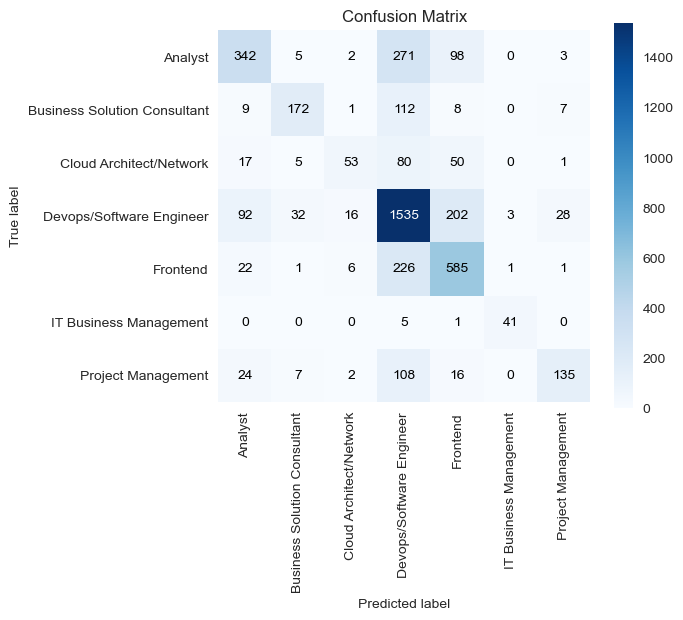

In [70]:
skplt.metrics.plot_confusion_matrix(
  y_test,
  random_forest_pred,
  x_tick_rotation=90,
  figsize= (6,5))

# 6. Determine Best Classification to use

**6.1 Accuracy**

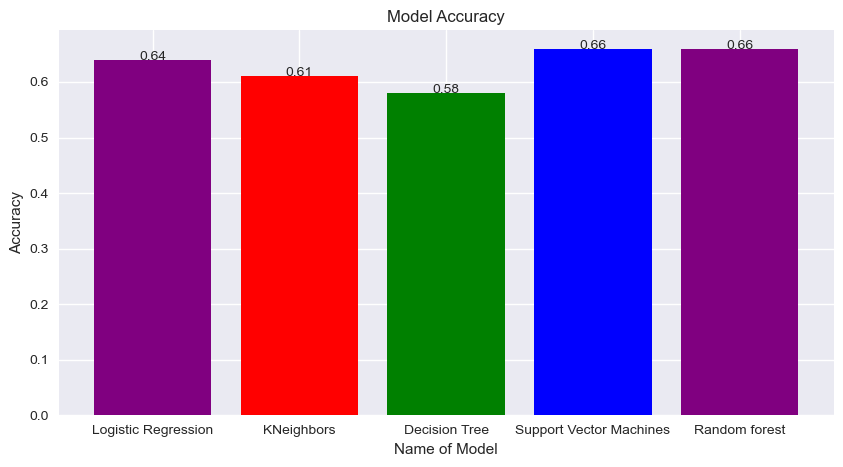

In [71]:
def addlabels(x,y):
    for i in range(len(x)):
        plt.text(i, y[i], y[i], ha = 'center')

# initializing the labels and model accuracy. The model accuracy round up to 2dp
labels = ("Logistic Regression", "KNeighbors", "Decision Tree", "Support Vector Machines","Random forest")
modelsAccuracy = [round(lrg_acc, 2),round(knn_acc, 2),round(dt_acc, 2), round (svm_acc, 2), round(random_forest_acc,2)]

# setting figure size by using figure() function
plt.figure(figsize = (10, 5))

# making the bar chart on the data
plt.bar (labels, modelsAccuracy, color=(['purple', 'red', 'green', 'blue']))

# calling the function to add value labels
addlabels(labels, modelsAccuracy)

# giving title to the plot
plt.title("Model Accuracy")

# giving X and Y labels
plt.xlabel("Name of Model")
plt.ylabel("Accuracy")
# visualizing the plot

plt. show()

**6.2 ROC**

In [45]:
# # predict probabilities
lrg_prob = lrg.predict_proba(X_test)[::,1]
knn_prob = knn.predict_proba(X_test)[::,1]
dt_prob = dt.predict_proba(X_test)[::,1]
svm_prob = svm.predict_proba(X_test)[:: ,1]
# roc curve for models
fprirg, tprirg, threshlrg = roc_curve(y_test, lrg_prob,pos_label='Business Solution Consultant')
fprknn, tprknn, threshknn = roc_curve(y_test, knn_prob, pos_label='Business Solution Consultant')
fprdt, tprdt, threshdt = roc_curve(y_test, dt_prob, pos_label='Business Solution Consultant')
fprsvm, tprsvm, threshsvm = roc_curve(y_test, svm_prob, pos_label='Business Solution Consultant')
# # roc curve for tpr = fpr
random_probs = [0 for i in range(len (y_test))]
P_fpr, p_tpr, _ = roc_curve (y_test, random_probs, pos_label ='Business Solution Consultant')

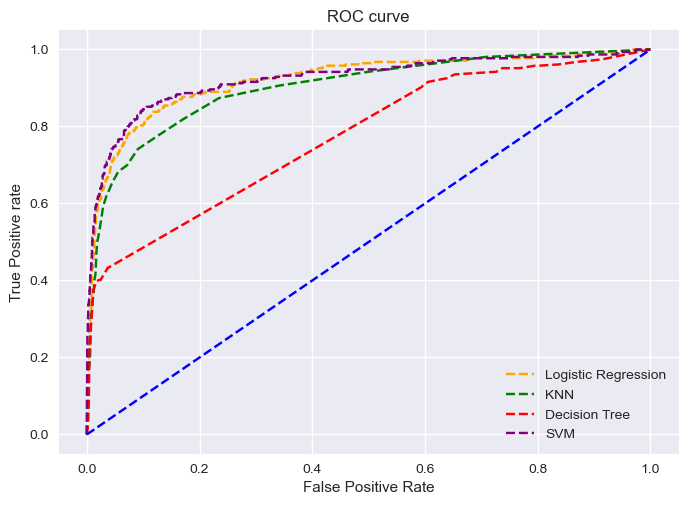

In [46]:
plt.style.use('seaborn')
# plot roc curves
plt.plot(fprirg, tprirg, linestyle='--',color ='orange', label='Logistic Regression')
plt.plot(fprknn, tprknn, linestyle='--',color ='green', label='KNN')
plt.plot(fprdt, tprdt, linestyle='--',color='red', label='Decision Tree')
plt.plot(fprsvm, tprsvm, linestyle='--' ,color='purple', label= 'SVM')
plt.plot(P_fpr, p_tpr, linestyle='--' , color='blue')
# title
plt.title('ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.legend(loc='best')
plt.savefig('ROC' ,dpi=300)
plt.show();

# 7 Data Analysis

**7.1 Finding out what are the skills needed for each job role**

**7.1.1 Frontend**

In [47]:
labelData = df_job[df_job['Label'] == "Frontend"]
skillsClass = []
for index, row in labelData.iterrows():
    skills = [row['skills']]
    skillstokens_without_sw = [f for f in skills if not f.lower () in stopwordsskills]
    for j in skillstokens_without_sw:
        skillsClass.append(j)

# put the cleaned skills into a new dataframe
df_frontend = pd.DataFrame({'skills':skillsClass})
qtySkills = df_frontend["skills"].value_counts().tolist()
labelSkills = df_frontend["skills"].value_counts().index.tolist ()

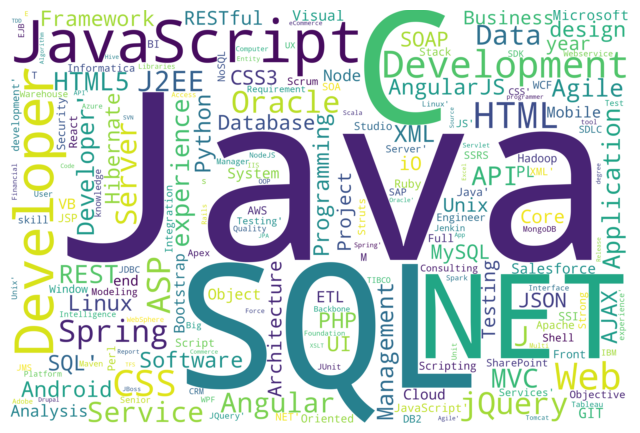

<Figure size 300000x300000 with 0 Axes>

In [48]:
lskills = labelSkills
frequencies = qtySkills
# Wordcloud asks for a string, and I have tried separating the terms with

d = dict(zip(lskills, frequencies))
wordcloud = w.WordCloud(collocations=False, random_state=1, background_color='white', width=3000, height=2000).generate(str(d))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")
plt.figure(figsize= (3000,3000))
plt.show()

**7.1.2 Analyst**

In [49]:
labelData = df_job[df_job['Label'] == "Analyst"]
skillsClass = []
for index, row in labelData.iterrows() :
    skills = [row['skills']]
    skillstokens_without_sw = [f for f in skills if not f.lower() in stopwordsskills]
    for j in skillstokens_without_sw:
        skillsClass.append(j)
# put the cleaned skills into a new dataframe
df_analyst = pd.DataFrame({'skills':skillsClass})

qtySkills = df_analyst["skills"].value_counts().tolist ()
labelSkills = df_analyst["skills"].value_counts().index.tolist ()

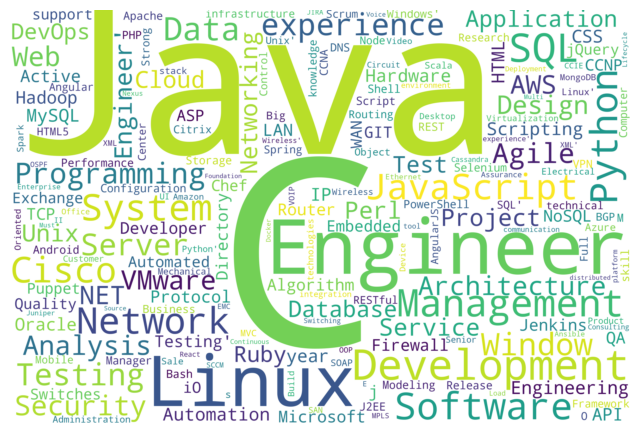

<Figure size 300000x300000 with 0 Axes>

In [50]:
lskills = labelSkills
frequencies = qtySkills
#Wordcloud asks for a string, and we have tried separating the terms

d = dict(zip(lskills, frequencies))
wordcloud = w.WordCloud(collocations=False, random_state=1,background_color='white',width=3000, height=2000).generate(str(d))
plt. imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")
plt.figure(figsize= (3000,3000))
plt.show ()

**7.1.3 Busines Solution Consultation**

In [51]:
labelData = df_job[df_job['Label'] == "Business Solution Consultant"]
skillsClass = []
for index,row in labelData.iterrows():
    skills = [row['skills']]
    skillstokens_without_sw = [f for f in skills if not f.lower() in stopwordsskills]
    for j in skillstokens_without_sw:
        skillsClass.append(j)
# put the cleaned skills into a new dataframe
df_consultant = pd.DataFrame({'skills':skillsClass})
qtySkills = df_consultant["skills"].value_counts().tolist()
labelSkills = df_consultant["skills"].value_counts().index.tolist()

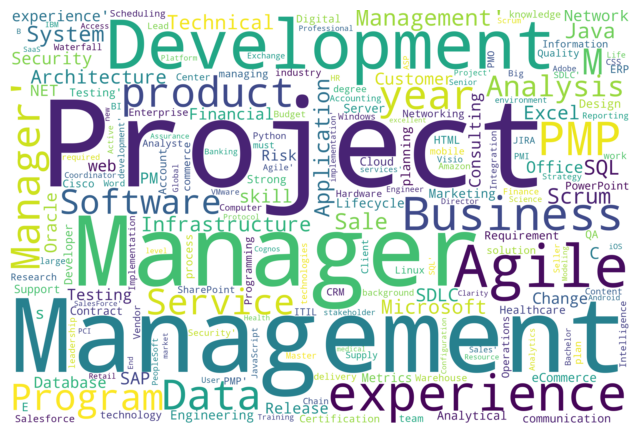

<Figure size 300000x300000 with 0 Axes>

In [52]:
lskills = labelSkills
frequencies = qtySkills
#Wordcloud asks for a string, and I have tried separating the terms with
d = dict(zip(lskills, frequencies))
wordcloud = w.WordCloud(collocations=False, random_state=1,background_color='white',width=3000, height=2000).generate(str(d))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")
plt.figure(figsize=(3000, 3000))
plt.show()


**7.1.4 Cloud Architect/Network**

In [53]:
labelData = df_job[df_job['Label'] == "Cloud Architect/Network"]
skillsClass = []
for index,row in labelData.iterrows():
    skills = [row['skills']]
    skillstokens_without_sw = [f for f in skills if not f.lower() in stopwordsskills]
    for j in skillstokens_without_sw:
        skillsClass.append(j)
# put the cleaned skills into a new dataframe
df_consultant = pd.DataFrame({'skills':skillsClass})
qtySkills = df_consultant["skills"].value_counts().tolist()
labelSkills = df_consultant["skills"].value_counts().index.tolist()

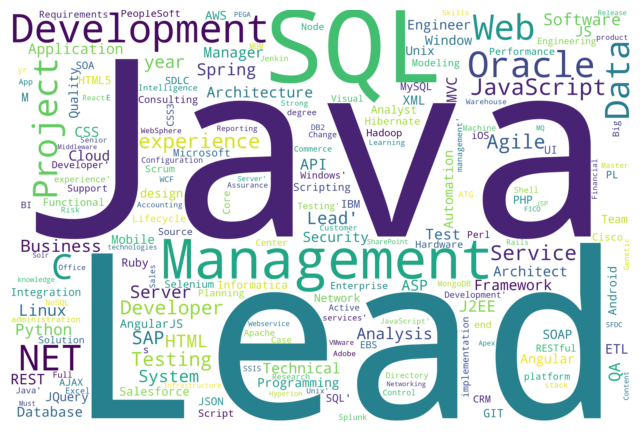

<Figure size 300000x300000 with 0 Axes>

In [54]:
lskills = labelSkills
frequencies = qtySkills
#Wordcloud asks for a string, and I have tried separating the terms with
d = dict(zip(lskills, frequencies))
wordcloud = w.WordCloud(collocations=False, random_state=1,background_color='white',width=3000, height=2000).generate(str(d))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")
plt.figure(figsize=(3000, 3000))
plt.show()


**7.1.5 Devops/Software Engineer**

In [55]:
labelData = df_job[df_job['Label'] == "Cloud Architect/Network"]
skillsClass = []
for index,row in labelData.iterrows():
    skills = [row['skills']]
    skillstokens_without_sw = [f for f in skills if not f.lower() in stopwordsskills]
    for j in skillstokens_without_sw:
        skillsClass.append(j)
# put the cleaned skills into a new dataframe
df_consultant = pd.DataFrame({'skills':skillsClass})
qtySkills = df_consultant["skills"].value_counts().tolist()
labelSkills = df_consultant["skills"].value_counts().index.tolist()

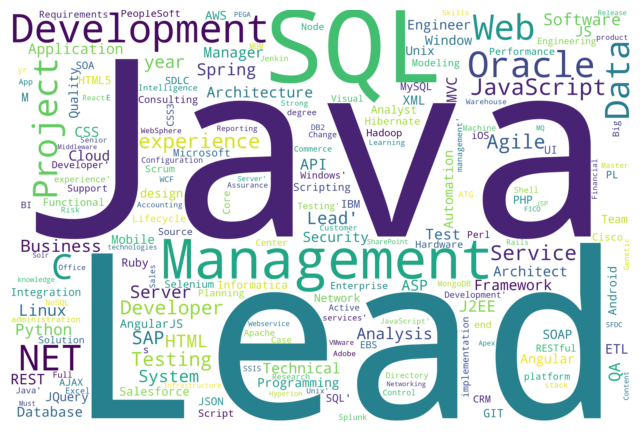

<Figure size 300000x300000 with 0 Axes>

In [56]:
lskills = labelSkills
frequencies = qtySkills
#Wordcloud asks for a string, and I have tried separating the terms with
d = dict(zip(lskills, frequencies))
wordcloud = w.WordCloud(collocations=False, random_state=1,background_color='white',width=3000, height=2000).generate(str(d))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")
plt.figure(figsize=(3000, 3000))
plt.show()

**7.1.6 IT Business Management**

In [57]:
labelData = df_job[df_job['Label'] == "IT Business Management"]
skillsClass = []
for index,row in labelData.iterrows():
    skills = [row['skills']]
    skillstokens_without_sw = [f for f in skills if not f.lower() in stopwordsskills]
    for j in skillstokens_without_sw:
        skillsClass.append(j)
# put the cleaned skills into a new dataframe
df_consultant = pd.DataFrame({'skills':skillsClass})
qtySkills = df_consultant["skills"].value_counts().tolist()
labelSkills = df_consultant["skills"].value_counts().index.tolist()

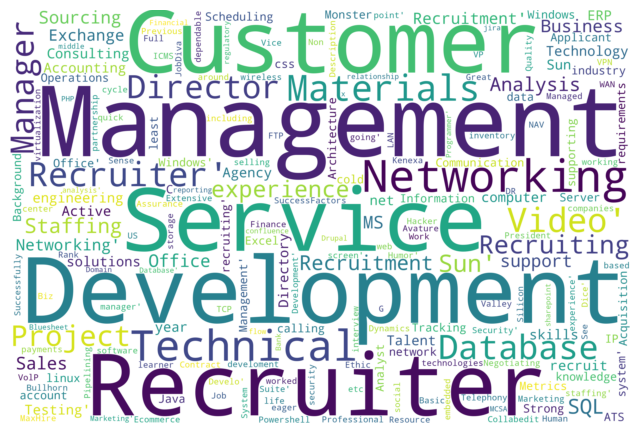

<Figure size 300000x300000 with 0 Axes>

In [58]:
lskills = labelSkills
frequencies = qtySkills
#Wordcloud asks for a string, and I have tried separating the terms with
d = dict(zip(lskills, frequencies))
wordcloud = w.WordCloud(collocations=False, random_state=1,background_color='white',width=3000, height=2000).generate(str(d))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")
plt.figure(figsize=(3000, 3000))
plt.show()

**7.1.7 Project Management**

In [59]:
labelData = df_job[df_job['Label'] == "Project Management"]
skillsClass = []
for index,row in labelData.iterrows():
    skills = [row['skills']]
    skillstokens_without_sw = [f for f in skills if not f.lower() in stopwordsskills]
    for j in skillstokens_without_sw:
        skillsClass.append(j)
# put the cleaned skills into a new dataframe
df_consultant = pd.DataFrame({'skills':skillsClass})
qtySkills = df_consultant["skills"].value_counts().tolist()
labelSkills = df_consultant["skills"].value_counts().index.tolist()

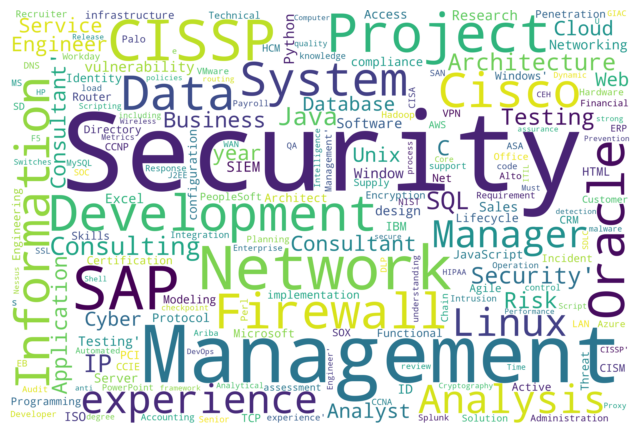

<Figure size 300000x300000 with 0 Axes>

In [60]:
lskills = labelSkills
frequencies = qtySkills
#Wordcloud asks for a string, and I have tried separating the terms with
d = dict(zip(lskills, frequencies))
wordcloud = w.WordCloud(collocations=False, random_state=1,background_color='white',width=3000, height=2000).generate(str(d))
plt.imshow(wordcloud, interpolation = 'bilinear')
plt.axis("off")
plt.figure(figsize=(3000, 3000))
plt.show()

**7. Get User Input**

In [61]:
userInput = input("Enter your skills: ")
pred = vectorizer.transform([userInput.lower()])

output = svm.predict(pred)
print(output[0])

Enter your skills: SQL, Python
Devops/Software Engineer


# 8.1 Cosine Similarity

In [62]:
cos = []
labelData = df_job[df_job['Label'] == output[0]]

for index,row in labelData.iterrows():
    skills = [row['skills']]
    skillVec = vectorizer.transform(skills)
    cos_lib = cosine_similarity(skillVec, pred)
    cos.append(cos_lib[0][0])
labelData['cosine_similarity'] = cos

In [63]:
#display top 5 recommendation from cosine similarity
top_5 = labelData.sort_values('cosine_similarity',ascending=False)[['advertiserurl','company','employmenttype_jobstatus','jobdescription','joblocation_address','jobtitle','skills','Label','cosine_similarity']]
top_5.head(5)

,advertiserurl,company,employmenttype_jobstatus,jobdescription,joblocation_address,jobtitle,skills,Label,cosine_similarity
21838,https://www.dice.com/jobs/detail/Performance-T...,"OSI Engineering, Inc.","Contract Corp-To-Corp, Contract Independent, C...",Responsibilities:• Design detailed performance...,"Santa Clara, CA",Performance Testing / Tuning Engineer,python,Devops/Software Engineer,0.803242
18605,https://www.dice.com/jobs/detail/Job-Opening-%...,Kutir Inc,"Full Time, Contract Corp-To-Corp, Contract Ind...",Role: QA Automation Engineer with PythonLocati...,"San Jose, CA",Job Opening - QA Automation Engineer with Pyth...,Python,Devops/Software Engineer,0.803242
9825,https://www.dice.com/jobs/detail/Python-Develo...,Eveear Tech,"Contract Corp-To-Corp, Contract Independent, C...",We have an urgent oprning with our client: Pyt...,"New York City, NY","Python Developer in New York City, NY",python,Devops/Software Engineer,0.803242
10178,https://www.dice.com/jobs/detail/Data-Analyst-...,Averity,Full Time,We are looking for a strong Data Analyst who p...,"New York, NY",Data Analyst at $6B Hedge Fund in Midtown,"SQL, Excel, Python, C#",Devops/Software Engineer,0.733691
20177,https://www.dice.com/jobs/detail/Programmer-An...,"Euronet Worldwide, Inc.",Full Time,Programmer Analyst This job might be for you ...,"Little Rock, AR",Programmer Analyst,"Java, C++, SQL, PHP, Python",Devops/Software Engineer,0.645569


# 8.2 Euclidean Distance

In [64]:
euclidean = []
labelData = df_job[df_job['Label'] == output[0]]

for index,row in labelData.iterrows():
    skills = [row['skills']]
    skillVec = vectorizer.transform(skills)
    euclidean_dist = euclidean_distances(skillVec,pred)
    euclidean.append(euclidean_dist[0][0])
labelData['euclidean_similarity'] = euclidean

In [65]:
#display top 5 recommendation from euclidean similarity
top_5 = labelData.sort_values('euclidean_similarity',ascending=False)[['advertiserurl','company','employmenttype_jobstatus','jobdescription','joblocation_address','jobtitle','skills','Label','euclidean_similarity']]
top_5.head(5)

,advertiserurl,company,employmenttype_jobstatus,jobdescription,joblocation_address,jobtitle,skills,Label,euclidean_similarity
17861,https://www.dice.com/jobs/detail/Cisco-Unified...,Pratt Brown & Associates,Contract W2,All candidates must possess an active TS/SCI C...,"Tampa, FL",Cisco Unified Capabilities Architect,"Cisco Unified Communications, Voice collaborat...",Devops/Software Engineer,1.414214
10676,https://www.dice.com/jobs/detail/Oracle-Fusion...,Peak Experience LLC,"Contract Corp-To-Corp, Contract Independent, C...",Title :Oracle SOA BA TechLead.Location : Allle...,"Allendale, NJ",Oracle Fusion Middleware Architect /SOA Archit...,"Business analasys ,Problem Solving , oracle SO...",Devops/Software Engineer,1.414214
4695,https://www.dice.com/jobs/detail/IT-Auditor-%2...,Costco Wholesale Corporation,Full Time,It is Internal Audit's responsibility to safeg...,"Issaquah, WA",IT Auditor ~,"Accounting, Analytical Skills, Excel, Manageme...",Devops/Software Engineer,1.414214
7884,https://www.dice.com/jobs/detail/Support-Cente...,"TEKsystems, Inc.",Full Time,We are currently looking for a Remote Support ...,"Towson, MD",Support Center Analyst,Support Center Analyst,Devops/Software Engineer,1.414214
17311,https://www.dice.com/jobs/detail/Data-Modeller...,Kavaliro,"Full Time, Contract Corp-To-Corp, Contract W2,...",Team is 22 people define enterprise logical/p...,"Herndon, VA",Data Modeller with ERstudio and Relational mod...,"Data Modeller, ERStudio, Relational Modelling,...",Devops/Software Engineer,1.414214


# 9.Final Job recommendation  

In [66]:
userInput = input("Enter your skills: ")
pred = vectorizer.transform([userInput.lower()])

output = svm.predict(pred)
print("You may look into " + output[0] + " jobs")
print("here is a list of jobs that is under "+ output[0])

cos = []
labelData = df_job[df_job['Label'] == output[0]]

for index,row in labelData.iterrows():
    skills = [row['skills']]
    skillVec = vectorizer.transform(skills)
    cos_lib = cosine_similarity(skillVec, pred)
    cos.append(cos_lib[0][0])
labelData['cosine_similarity'] = cos

#display top 5 recommendation from cosine similarity
top_5 = labelData.sort_values('cosine_similarity',ascending=False)[['advertiserurl','company','employmenttype_jobstatus','jobdescription','joblocation_address','jobtitle','skills','Label']]
top_5.head(5)

Enter your skills: SQL,Python
You may look into Devops/Software Engineer jobs
here is a list of jobs that is under Devops/Software Engineer


,advertiserurl,company,employmenttype_jobstatus,jobdescription,joblocation_address,jobtitle,skills,Label
21838,https://www.dice.com/jobs/detail/Performance-T...,"OSI Engineering, Inc.","Contract Corp-To-Corp, Contract Independent, C...",Responsibilities:• Design detailed performance...,"Santa Clara, CA",Performance Testing / Tuning Engineer,python,Devops/Software Engineer
18605,https://www.dice.com/jobs/detail/Job-Opening-%...,Kutir Inc,"Full Time, Contract Corp-To-Corp, Contract Ind...",Role: QA Automation Engineer with PythonLocati...,"San Jose, CA",Job Opening - QA Automation Engineer with Pyth...,Python,Devops/Software Engineer
9825,https://www.dice.com/jobs/detail/Python-Develo...,Eveear Tech,"Contract Corp-To-Corp, Contract Independent, C...",We have an urgent oprning with our client: Pyt...,"New York City, NY","Python Developer in New York City, NY",python,Devops/Software Engineer
10178,https://www.dice.com/jobs/detail/Data-Analyst-...,Averity,Full Time,We are looking for a strong Data Analyst who p...,"New York, NY",Data Analyst at $6B Hedge Fund in Midtown,"SQL, Excel, Python, C#",Devops/Software Engineer
20177,https://www.dice.com/jobs/detail/Programmer-An...,"Euronet Worldwide, Inc.",Full Time,Programmer Analyst This job might be for you ...,"Little Rock, AR",Programmer Analyst,"Java, C++, SQL, PHP, Python",Devops/Software Engineer


In [72]:
import pickle

In [74]:
pickle.dump(svmfit,open('model.pkl','wb'))

In [77]:
model = pickle.load(open('model.pkl','rb'))